In [30]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier



In [31]:
df_ransomware = pd.read_csv("../datasets/ransomware.csv")

df_ransomware.head()

,FileName,md5Hash,Machine,DebugSize,DebugRVA,MajorImageVersion,MajorOSVersion,ExportRVA,ExportSize,IatVRA,MajorLinkerVersion,MinorLinkerVersion,NumberOfSections,SizeOfStackReserve,DllCharacteristics,ResourceSize,BitcoinAddresses,Benign
0,0124e21d-018c-4ce0-92a3-b9e205a76bc0.dll,79755c51e413ed3c6be4635fd729a6e1,332,0,0,0,4,0,0,8192,8,0,3,1048576,34112,672,0,1
1,05c8318f98a5d301d80000009c316005.vertdll.dll,95e19f3657d34a432eada93221b0ea16,34404,84,121728,10,10,126576,4930,0,14,10,8,262144,16864,1024,0,1
2,06054fba-5619-4a86-a861-ffb0464bef5d.dll,85c32641d77a54e19ba8ea4ab305c791,332,0,0,0,4,0,0,8192,8,0,3,1048576,34112,672,0,1
3,075822ac99a5d301660400009c316005.adhapi.dll,62e3b959d982ef534b66f819fe15f085,34404,84,19904,10,10,21312,252,18160,14,10,6,262144,16736,1040,0,1
4,090607dd9ba5d301ca0900009c316005.SensorsNative...,ae38c5f7d313ad0ff3bfb8826476767f,34404,84,97728,10,10,105792,1852,70592,14,10,7,262144,16736,1096,0,1


In [32]:
df_ransomware = df_ransomware.drop(columns=["md5Hash", "FileName", "BitcoinAddresses", ])

df_ransomware.to_csv("../datasets/ransomware_transformado.csv", index=False, decimal=".", sep=";")
display(df_ransomware.head())


,Machine,DebugSize,DebugRVA,MajorImageVersion,MajorOSVersion,ExportRVA,ExportSize,IatVRA,MajorLinkerVersion,MinorLinkerVersion,NumberOfSections,SizeOfStackReserve,DllCharacteristics,ResourceSize,Benign
0,332,0,0,0,4,0,0,8192,8,0,3,1048576,34112,672,1
1,34404,84,121728,10,10,126576,4930,0,14,10,8,262144,16864,1024,1
2,332,0,0,0,4,0,0,8192,8,0,3,1048576,34112,672,1
3,34404,84,19904,10,10,21312,252,18160,14,10,6,262144,16736,1040,1
4,34404,84,97728,10,10,105792,1852,70592,14,10,7,262144,16736,1096,1


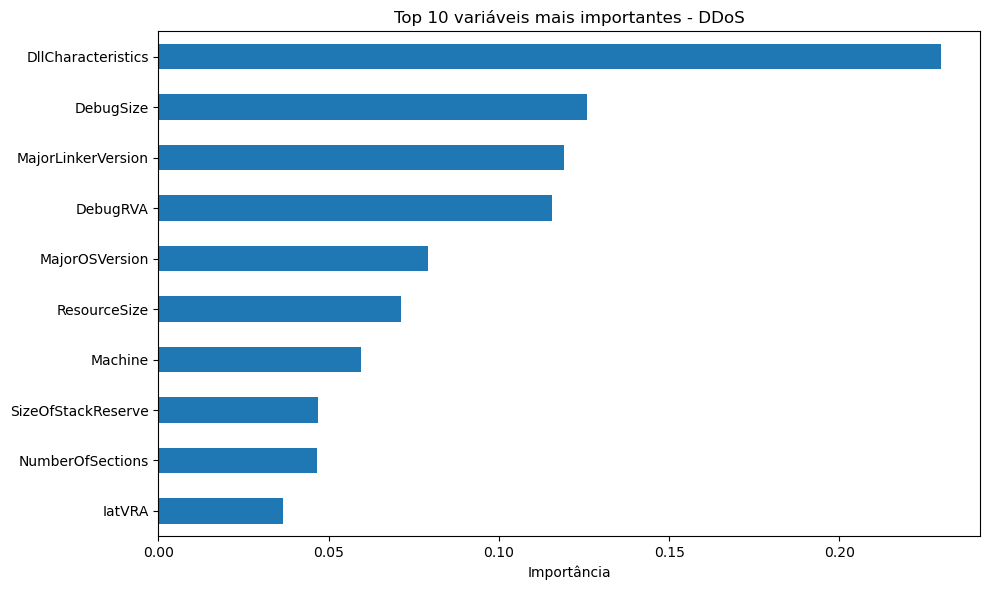

,importance
DllCharacteristics,0.229824
DebugSize,0.125821
MajorLinkerVersion,0.119026
DebugRVA,0.115561
MajorOSVersion,0.079164
ResourceSize,0.071146
Machine,0.059577
SizeOfStackReserve,0.046746
NumberOfSections,0.046627
IatVRA,0.036544


In [33]:
# OBS: para avaliação adequada, o ideal é separar treino/teste ou usar validação cruzada.
# Aqui focamos na importância de features, como no seu código original.
Y = df_ransomware["Benign"]
X = df_ransomware.drop(columns="Benign")

modelo = RandomForestClassifier()
modelo.fit(X, Y)

importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)

top_n = 10
plt.figure(figsize=(10, 6))
importancias.head(top_n).plot(kind="barh")
plt.title(f"Top {top_n} variáveis mais importantes - DDoS")
plt.xlabel("Importância")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

display(importancias.head(25).to_frame("importance"))
